# Minimal CNN Architecture for CSD Nuclearity Prediction

This notebook explores a significantly simplified CNN architecture to determine the minimal model complexity needed for accurate nuclearity prediction from PDF data.

**Simplifications compared to standard model:**
- Single Conv1D layer (vs. two)
- GlobalAveragePooling1D instead of Flatten (dramatically reduces parameters)
- Smaller filter counts: [4, 8, 16]
- Smaller kernel sizes: [32, 64, 128]
- Single Dense layer before output
- Reduced dropout complexity

In [1]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from keras.models import Sequential
from keras.layers import Dense, Conv1D, GlobalAveragePooling1D, MaxPooling1D, Flatten, Dropout
from keras.callbacks import History, ModelCheckpoint, EarlyStopping
from keras import backend as K
from keras import metrics, regularizers
from keras.optimizers import Adam, Adagrad, Adadelta, RMSprop
from keras_tuner import RandomSearch, Hyperband
from keras_tuner.engine.hyperparameters import HyperParameters
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
import keras.regularizers
import keras
import glob
import os
import itertools
import fnmatch

# Import path configuration
import sys
import importlib
sys.path.insert(0, '../..')  # Add root directory to path (two levels up from architecture_comparison/)

# Force reload to pick up any config changes
import config
importlib.reload(config)
from config import setup_workdir, get_path

In [2]:
# Set working directory to CSD calculated PDFs
setup_workdir('csd_calculated_pdfs')

Working directory: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/csd_structures/calculated_pdfs


In [3]:
# Get calculated PDFs from the CSD structures folder
csd_pdfs_dir = get_path('csd_calculated_pdfs')
files_calc = glob.glob(str(csd_pdfs_dir / '*.dat'))

Counts of CSD structures by their nuclearity: {'1': 70, '2': 166, '3': 6, '4': 99, '5': 7, '6': 22, '7': 14, '8': 17, '9': 30, 'polymer': 214}
Total number of structures: 645


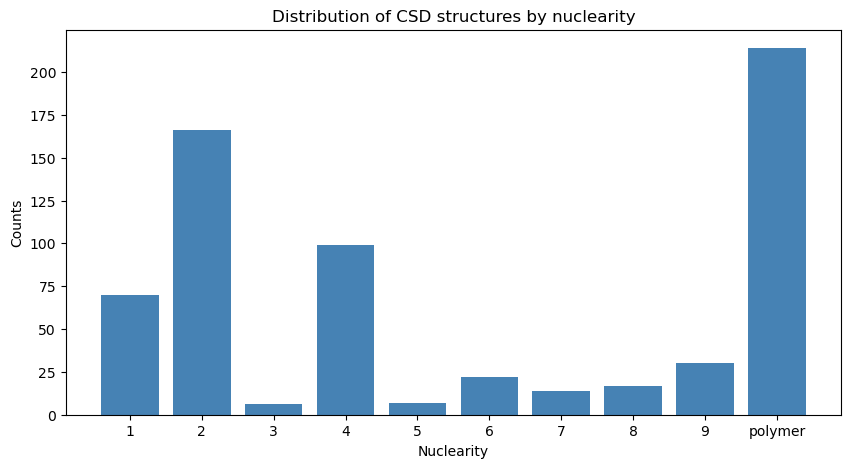

In [4]:
from collections import defaultdict
import matplotlib.pyplot as plt

def analyze_filenames(filenames):
    # Count how many filenames start with each digit from 1 to 9, plus 'p' for 10
    counts = defaultdict(int)
    for filepath in filenames:
        filename = os.path.basename(filepath)
        if filename[0].isdigit() and filename[0] != '0':
            counts[filename[0]] += 1
        elif filename[0] == 'p':
            counts['10'] += 1
            
    return counts

counts = analyze_filenames(files_calc)
# Include nuclearity 10 for CSD structures (coordination polymers)
sorted_counts = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
sorted_counts['polymer'] = counts.get('10', 0)

print("Counts of CSD structures by their nuclearity:", sorted_counts)
print(f"Total number of structures: {len(files_calc)}")

digits = list(sorted_counts.keys())
values = list(sorted_counts.values())

plt.figure(figsize=(10, 5))
plt.bar(digits, values, color='steelblue')
plt.xlabel('Nuclearity')
plt.ylabel('Counts')
plt.title('Distribution of CSD structures by nuclearity')
plt.show()

In [5]:
# Setup output directories - using separate folder for minimal model
labels_dir = get_path('labels')
models_dir = get_path('csd_models').parent / 'csd_minimal'
labels_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

labels_file = labels_dir / 'csd_labels.txt'

raw_data_points = []

with open(labels_file, 'w') as labels_out:
    for f in files_calc:
        df = pd.read_csv(f, usecols=[1], skiprows=201, header=None, delim_whitespace=True, skipfooter=800, engine='python')
        raw_data_points.append(df.values.ravel())
        # Extract just the filename from the full path
        filename = os.path.basename(f)
        if filename[0] == 'p':
            labels_out.write('10')
            labels_out.write('\n')
        else:    
            labels_out.write(filename[0])
            labels_out.write('\n')

raw_data_points = np.array(raw_data_points)

# Load the labels
labels = pd.read_csv(labels_file, header=None)
labels = labels.values.ravel()  # convert the labels to a 1D array

print(f"Labels saved to: {labels_file}")
print(f"Models will be saved to: {models_dir}")

Labels saved to: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/labels/csd_labels.txt
Models will be saved to: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/models/csd_minimal


10


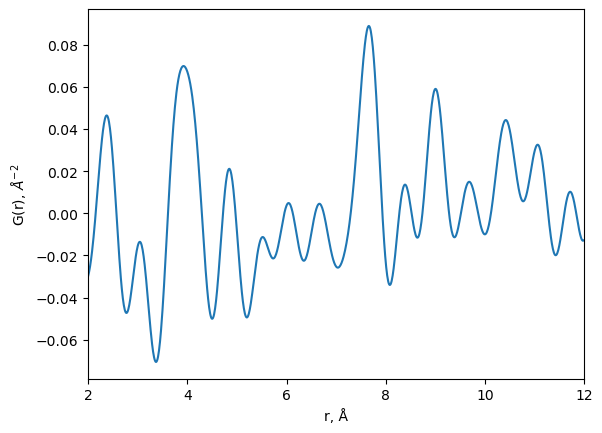

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)
fig, ax = plt.subplots()
ax.set_xlim(2,12)
ax.plot(np.arange(len(data_points[77,:]))/100+2, data_points[77,:])
plt.xlabel('r, Å')
plt.ylabel('G(r), $Å^{-2}$')
print(labels[77])

## Minimal Architecture Hyperparameter Tuning

The minimal model uses:
- Single Conv1D layer with reduced filter options
- One Dense hidden layer
- Output layer

In [ ]:
# Hyperparameter tuning for minimal architecture

def build_model(hp):
    model = Sequential()
    
    # Single Conv1D layer with smaller filter counts
    model.add(Conv1D(filters=hp.Choice('filters', [4, 8, 16]),
                     kernel_size=hp.Choice('kernel_size', [32, 64, 128]),
                     activation='relu', 
                     input_shape=(1000, 1)))
    
    # Optional pooling
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout1', 0.1, 0.5, step=0.1)))
    
    # Flatten the output
    model.add(Flatten())
    
    # Single dense layer
    model.add(Dense(units=hp.Choice('dense_units', [16, 32, 64]), 
                    activation='relu',
                    kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(hp.Float('dropout2', 0.1, 0.5, step=0.1)))
    
    # Output layer
    model.add(Dense(units=11, activation='softmax', 
                    kernel_regularizer=keras.regularizers.l2(0.01)))
    
    optimizer = Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-2, sampling='log'))
    model.compile(optimizer=optimizer, 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

In [12]:
X_train, X_val, y_train, y_val = train_test_split(data_points, labels, test_size=0.2, random_state=42)

# Setup hyperband directory within models folder
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=200,
    factor=3,
    directory=str(models_dir),
    project_name='hyperband_minimal_csd'
)

tuner.search(X_train, y_train, epochs=200, validation_data=(X_val, y_val), 
             callbacks=[EarlyStopping(monitor='val_loss', patience=5)])
tuner.search_space_summary()
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(best_hyperparameters.values)

# Extract best hyperparameters for retraining
best_filters = best_hyperparameters.get('filters')
best_kernel_size = best_hyperparameters.get('kernel_size')
best_dropout1 = best_hyperparameters.get('dropout1')
best_dropout2 = best_hyperparameters.get('dropout2')
best_dense_units = best_hyperparameters.get('dense_units')
best_learning_rate = best_hyperparameters.get('learning_rate')

print(f"\nExtracted hyperparameters for retraining:")
print(f"  filters: {best_filters}, kernel_size: {best_kernel_size}")
print(f"  dropout1: {best_dropout1}, dropout2: {best_dropout2}")
print(f"  dense_units: {best_dense_units}")
print(f"  learning_rate: {best_learning_rate}")

best_model = tuner.get_best_models(num_models=1)[0]

# Save best model to models directory
best_model_path = models_dir / 'tuned_minimal_csd.h5'
best_model.save(best_model_path)
print(f"\nBest model saved to: {best_model_path}")

# Print model summary to see parameter count
print("\nModel architecture summary:")
best_model.summary()

Trial 254 Complete [00h 00m 03s]
val_accuracy: 0.7054263353347778

Best val_accuracy So Far: 0.8062015771865845
Total elapsed time: 00h 12m 52s
INFO:tensorflow:Oracle triggered exit
Search space summary
Default search space size: 6
filters (Choice)
{'default': 4, 'conditions': [], 'values': [4, 8, 16], 'ordered': True}
kernel_size (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
dropout1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
dense_units (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dropout2 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
Best hyperparameters:
{'filters': 8, 'kernel_size': 32, 'dropout1': 0.5, 'dense_units': 32, 'dropout2': 0.1

In [13]:
def create_model():
    # Create minimal model using best hyperparameters from tuning
    model = Sequential()
    
    # Single Conv1D layer
    model.add(Conv1D(filters=best_filters, 
                     kernel_size=best_kernel_size, 
                     activation='relu', 
                     input_shape=(1000, 1)))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(best_dropout1))
    
    # Flatten the output (matching build_model)
    model.add(Flatten())
    
    # Single dense layer
    model.add(Dense(units=best_dense_units, 
                    activation='relu', 
                    kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(best_dropout2))
    
    # Output layer
    model.add(Dense(units=11, activation='softmax', 
                    kernel_regularizer=keras.regularizers.l2(0.01)))

    # Compile the model with the best learning rate
    optimizer = Adam(learning_rate=best_learning_rate)
    model.compile(optimizer=optimizer, 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

    return model

In [14]:
num_folds = 10
num_epochs = 200
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
fold_num = 1 
all_fold_results = []
histories = []

In [15]:
# Setup directory for fold models
folds_dir = models_dir / 'cv_folds'
folds_dir.mkdir(parents=True, exist_ok=True)

for train_index, val_index in kf.split(data_points):
    X_train, X_val = data_points[train_index], data_points[val_index]
    y_train, y_val = labels[train_index], labels[val_index]

    model = create_model()

    checkpoint_path = folds_dir / f"minimal_fold_{fold_num}_model.h5"
    checkpoint = ModelCheckpoint(str(checkpoint_path), monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

    print(f'Training fold {fold_num}...')
    history = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[checkpoint])
    histories.append(history)

    # Load the best model saved by the checkpoint and evaluate
    load_model = keras.models.load_model(str(checkpoint_path))
    
    val_loss, val_acc = load_model.evaluate(X_val, y_val)
    print(f'Fold {fold_num} accuracy:', val_acc)

    all_fold_results.append(val_acc)

    fold_num += 1

# Print overall performance across all folds
print('All fold accuracies:', all_fold_results)
print('Mean accuracy:', np.mean(all_fold_results))
print('Standard deviation:', np.std(all_fold_results))
print(f"\nFold models saved to: {folds_dir}")

Training fold 1...
Epoch 1/200
13/19 [===================>..........] - ETA: 0s - loss: 2.5969 - accuracy: 0.3245
Epoch 1: val_accuracy improved from -inf to 0.38462, saving model to /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/models/csd_minimal/cv_folds/minimal_fold_1_model.h5
19/19 [==============================] - 1s 15ms/step - loss: 2.4388 - accuracy: 0.3362 - val_loss: 2.1701 - val_accuracy: 0.3846
Epoch 2/200
16/19 [========================>.....] - ETA: 0s - loss: 1.7738 - accuracy: 0.5234
Epoch 2: val_accuracy improved from 0.38462 to 0.60000, saving model to /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/models/csd_minimal/cv_folds/minimal_fold_1_model.h5
19/19 [==============================] - 0s 16ms/step - loss: 1.7666 - accuracy: 0.5276 - val_loss: 1.6904 - val_accuracy: 0.6000
Epoch 3/200
16/19 [========================>.....] - ETA: 0s - loss: 1.4828 - accuracy: 0.6270
Epoch 3: val_accuracy improved from

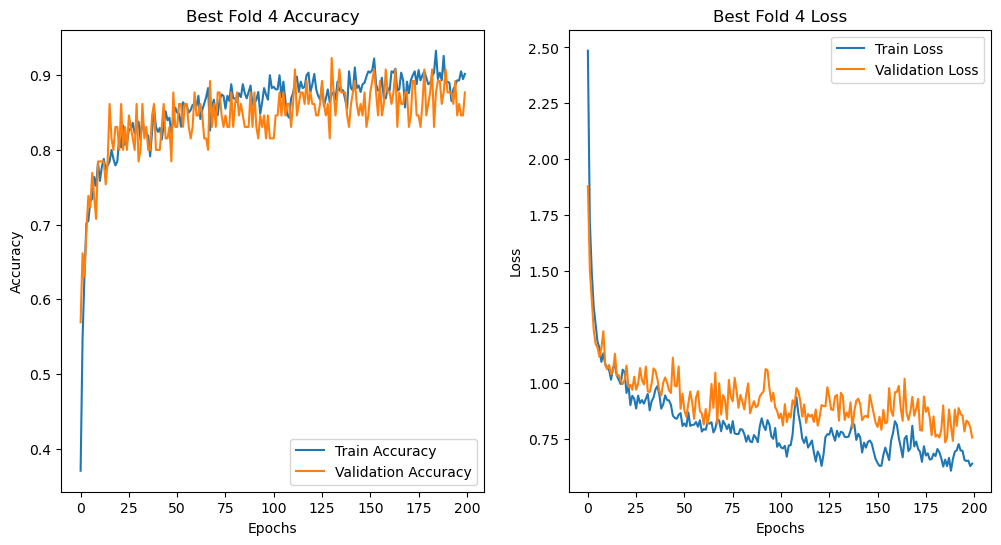

In [16]:
# Identifying the best fold (assuming higher validation accuracy is better)
best_fold_index = np.argmax([np.max(hist.history['val_accuracy']) for hist in histories])

# Plotting metrics for the best fold
best_history = histories[best_fold_index]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'], label='Train Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
plt.title(f'Best Fold {best_fold_index + 1} Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title(f'Best Fold {best_fold_index + 1} Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Model Evaluation and Confusion Matrix

Loading best model from fold 4: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/models/csd_minimal/cv_folds/minimal_fold_4_model.h5

Model parameter count:
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_4 (Conv1D)           (None, 969, 8)            264       
                                                                 
 max_pooling1d_4 (MaxPooling  (None, 484, 8)           0         
 1D)                                                             
                                                                 
 dropout_8 (Dropout)         (None, 484, 8)            0         
                                                                 
 flatten_4 (Flatten)         (None, 3872)              0         
                                                                 
 dense_8 (Dense)             (None, 32)                123936    


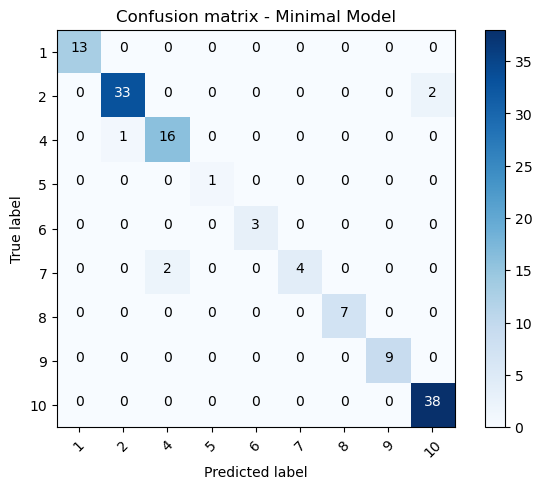

In [17]:
X_train, X_val, y_train, y_val = train_test_split(data_points, labels, test_size=0.2, random_state=42)

# Load the best model from cross-validation (best fold determined from training)
best_fold = np.argmax(all_fold_results) + 1  # +1 because fold_num starts at 1
best_model_path = models_dir / 'cv_folds' / f'minimal_fold_{best_fold}_model.h5'
print(f"Loading best model from fold {best_fold}: {best_model_path}")

load_model = keras.models.load_model(best_model_path)

print("\nModel parameter count:")
load_model.summary()

load_model.evaluate(X_val, y_val)
y_pred_prob = load_model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_val, y_pred)
recall = recall_score(y_val, y_pred, average=None)
f1 = f1_score(y_val, y_pred, average=None)
precision = precision_score(y_val, y_pred, average=None)
#print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_val), title='Confusion matrix - Minimal Model', normalize=False)
plt.show()

## Saliency Map Analysis

Even with the minimal architecture, we can still analyze which PDF features drive predictions.

Sample label: 6


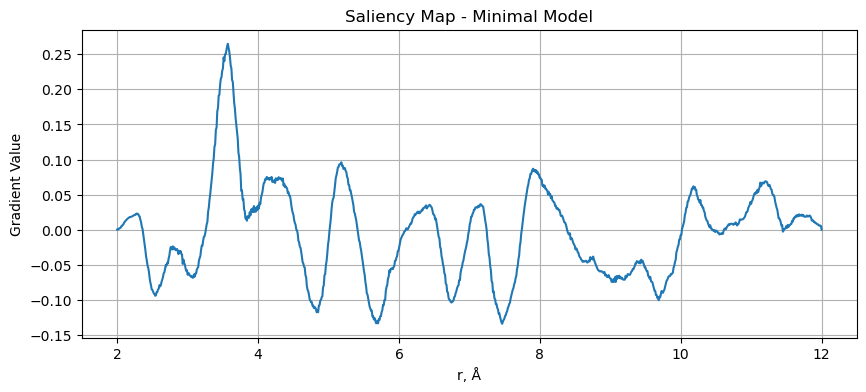

In [18]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Use the loaded model from cross-validation
model = load_model

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

sample_index = 5  
sample_label = y_train[sample_index]
some_input = tf.convert_to_tensor(X_train[sample_index].reshape(1, 1000, 1), dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(some_input)
    prediction = model(some_input)
    loss = prediction[0][sample_label]

grad_values = tape.gradient(loss, some_input)
grad_numpy = grad_values.numpy().reshape(1000)
print(f"Sample label: {y_train[sample_index]}")
angstrom_range = 2 + np.linspace(0, 1000, 1000) / 100

# Plot
plt.figure(figsize=(10, 4))
plt.plot(angstrom_range, grad_numpy)
plt.title('Saliency Map - Minimal Model')
plt.xlabel('r, Å')
plt.ylabel('Gradient Value')
plt.grid(True)
plt.show()

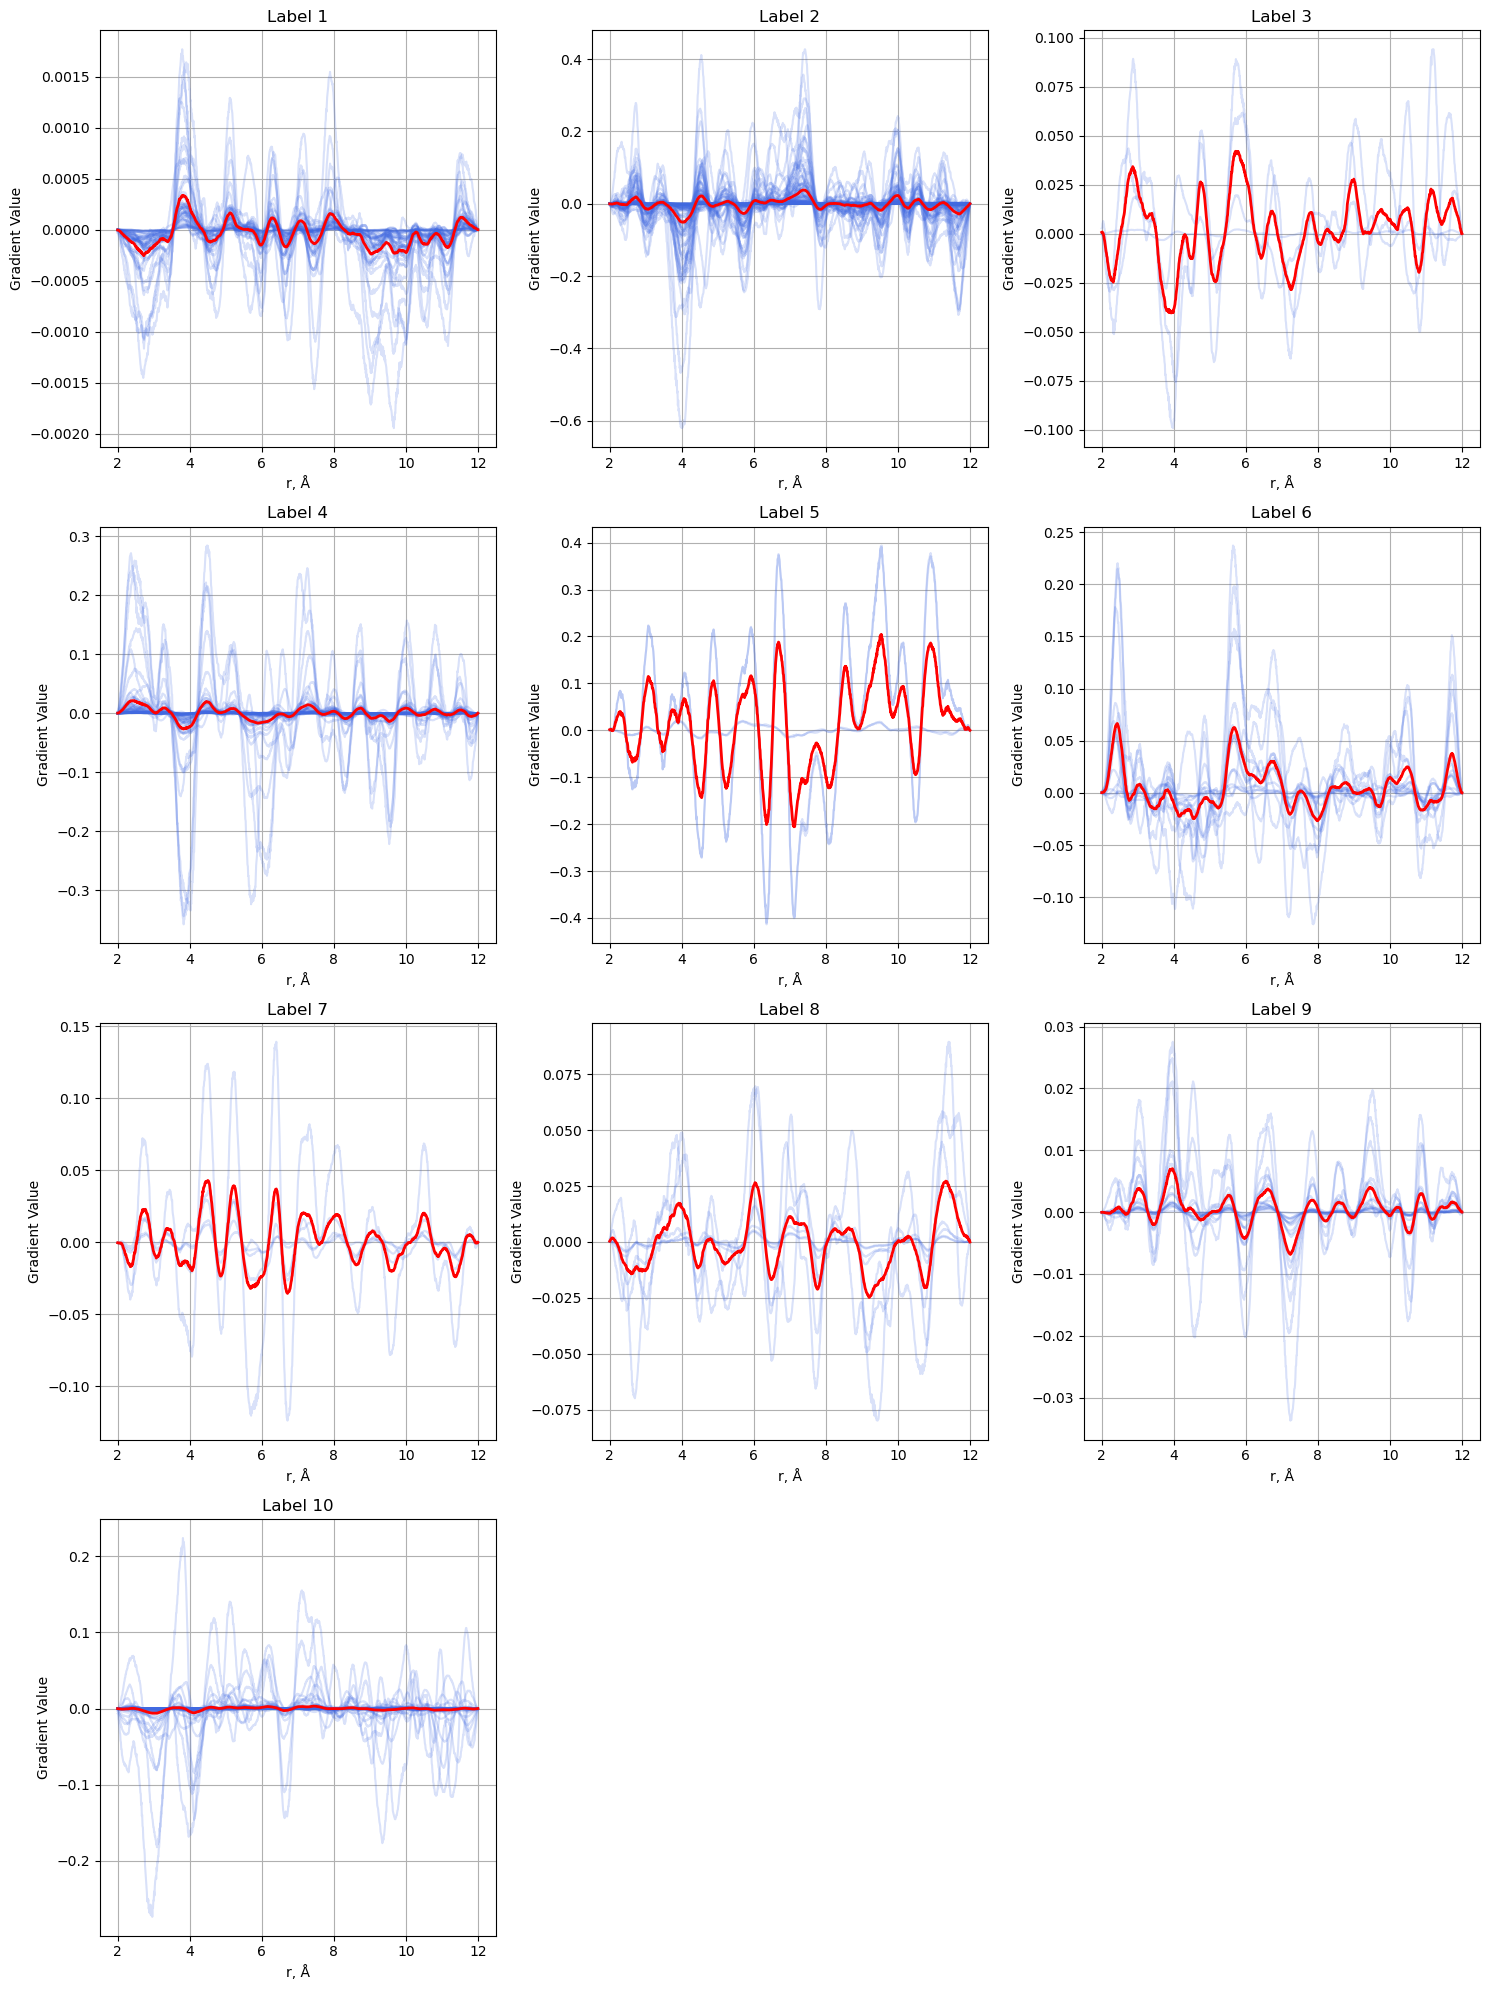


Saliency maps show which r-ranges most influence predictions for each nuclearity class.


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

sample_size = 400
fig, axes = plt.subplots(4, 3, figsize=(15, 20))

# Loop through the unique labels (from 1 to 10)
for label in range(1, 11):
    ax = axes[(label - 1) // 3, (label - 1) % 3]
    gradients = []
    
    # Loop through first `sample_size` samples to check for this label
    for idx in range(min(sample_size, len(y_train))):
        if y_train[idx] == label:
            sample_input = tf.convert_to_tensor(X_train[idx].reshape(1, 1000, 1), dtype=tf.float32)
            
            with tf.GradientTape() as tape:
                tape.watch(sample_input)
                prediction = model(sample_input)
                loss = prediction[0][label - 1]  # Adjust for 0-based index
            
            grad_values = tape.gradient(loss, sample_input)
            grad_numpy = grad_values.numpy().reshape(1000)
            gradients.append(grad_numpy)
            
            angstrom_range = 2 + np.linspace(0, 1000, 1000) / 100
            ax.plot(angstrom_range, grad_numpy, alpha=0.2, color='royalblue')
    
    # Plot the average line if we have any gradients for this label
    if gradients:
        mean_gradient = np.mean(gradients, axis=0)
        ax.plot(angstrom_range, mean_gradient, color='red', linewidth=2)
    
    ax.set_title(f'Label {label}')
    ax.set_xlabel('r, Å')
    ax.set_ylabel('Gradient Value')
    ax.grid(True)

fig.delaxes(axes[3,1])
fig.delaxes(axes[3,2])

plt.tight_layout()

# Save to figures directory
figures_dir = get_path('figures')
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / 'csd_minimal_saliency_maps.png', dpi=400)
plt.show()

print("\nSaliency maps show which r-ranges most influence predictions for each nuclearity class.")